# Olivetti Eigenfaces, PCA and SVD

## Data-driven modeling

This Python code demonstrates how to import  the Olivetti faces dataset and apply principal component analysis (PCA) to find *eigenfaces*.

This notebook is hosted on Google colab and based on Jupyter notebook - this means you don't have to install jupyter or python locally to run this code. You can directly edit this notebook online - make your own copy by going to `File` > `Save a copy in Drive` in the menu bar.


In [ ]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

dataset = fetch_olivetti_faces(shuffle=True)  # import faces shuffled
print(dataset.DESCR)  # print description

X = dataset.data.T  # transpose data matrix so individual faces are column vectors
X =  X - np.mean(X)   # mean center the data


Xtest = X[:,0:50]  # divide into test data
ytest = dataset.target[0:50]

Xtrain = X[:,51:]  # and training data
ytrain = dataset.target[51:]

N,M = Xtrain.shape

.. _olivetti_faces_dataset:

The Olivetti faces dataset
--------------------------

`This dataset contains a set of face images`_ taken between April 1992 and
April 1994 at AT&T Laboratories Cambridge. The
:func:`sklearn.datasets.fetch_olivetti_faces` function is the data
fetching / caching function that downloads the data
archive from AT&T.

.. _This dataset contains a set of face images: https://cam-orl.co.uk/facedatabase.html

As described on the original website:

    There are ten different images of each of 40 distinct subjects. For some
    subjects, the images were taken at different times, varying the lighting,
    facial expressions (open / closed eyes, smiling / not smiling) and facial
    details (glasses / no glasses). All the images were taken against a dark
    homogeneous background with the subjects in an upright, frontal position
    (with tolerance for some side movement).

**Data Set Characteristics:**

=================   =====================
Classes              

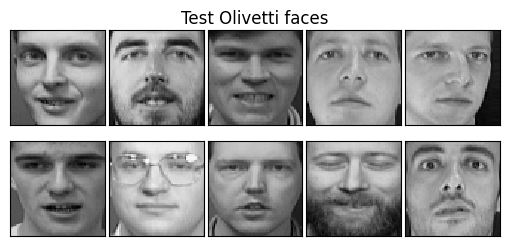

In [ ]:
# This function reshapes and plots the images in an n_row x n_col grid
def plot_gallery(title, images, n_col=4, n_row=2):
    plt.figure(figsize=(1. * n_col, 1.26 * n_row))
    plt.suptitle(title, size=12)
    image_shape = (64, 64)

    for i in range(min(images.shape)):
        plt.subplot(n_row, n_col, i + 1)
        comp = images[:,i]
        vmax = max(comp.max(), -comp.min())
        plt.imshow(comp.reshape(image_shape), cmap=plt.cm.gray,
                   interpolation='nearest',
                   vmin=-vmax, vmax=vmax)
        plt.xticks(())
        plt.yticks(())
    plt.subplots_adjust(0.01, 0.05, 0.99, 0.93, 0.04, 0.)

plot_gallery("Test Olivetti faces", Xtest[:,39:49],5,2)




# Compute the singular value decomposition

Compute the reduced SVD of mean-centered training data $X_{train}-\bar{X}$
$$ X_{cent} = U\Sigma V^T $$
The rank $r$ approximation to the data using the first $r$ left (eigenfaces) and right singular vectors, and singular values is given by
$$ X_r = U_r \Sigma_r V_r^T.  $$

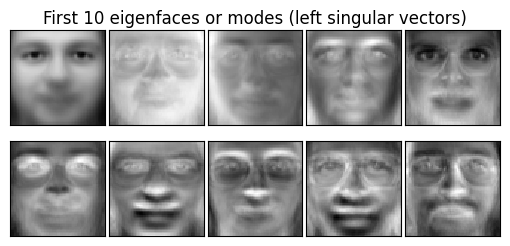

In [ ]:
[U,sigma,Vt] = np.linalg.svd(Xtrain,full_matrices=False)  # Reduced SVD
plot_gallery("First 10 eigenfaces or modes (left singular vectors)", U[:,0:10],5,2)

# Low-rank approximation

1. A rank-$r$ approximation of a face $x$ is computed using the orthogonal projection of $x$ onto the leading $r$ left singular vectors (principal components)
$$ {\hat{x}} = \sum_{i=1}^r \langle u_i,x \rangle u_i$$
Suppose $U_r$ is the matrix composed of the leading $r$ left singular vectors as its columns. Express this rank-$r$ approximation in matrix notation in terms of $U_r$ and $x$:
$$ \hat{x} = U_r \cdot ?$$
Complete the following code block to compute the rank 10 approximation of Test Image 12 (this image was not used to train the eigenface/SVD model and hence belongs to the *test* set of unseen images).

In [ ]:
# Rank r approximation of test subject

r = 10
Ur = U[:,0:r]
x = Xtest[:,12]
xhat = Ur @ # Complete this line ("@" operator is matrix multiplication)
plot_gallery("Rank r approximation",np.column_stack((x,xhat)),2,1)

SyntaxError: invalid syntax (<ipython-input-4-7802dae3c92b>, line 6)

2. The percentage of the variance described  by the leading $r$ PCs is given by
$$ \frac{\sum_{i=1}^r\sigma_i^2}{\sum_{i=1}^M\sigma_i^2}\times 100,$$
where $\sigma_i=\Sigma_{ii}$ are the diagonal entries of $\Sigma$ of the SVD.
What percentage of the variance in *this* data is described by the first principal component? The first three PCs? The first 150 PCs? Modify the following code to compute and print the answers using the variable `sigma`. You may find `np.sum()` useful.

In [ ]:
print(sigma[0])

print(sigma[0])

print(sigma[0])

129.53038
129.53038
129.53038


3. How many PCs does it take to describe at least $70\%$ of the variance in the data? Visualize the corresponding rank approximation for Q1 using `plot_gallery()`.

---



In [ ]:
z = # complete this line
plot_gallery("70\% variance explained",np.column_stack((x,z)),2,1)

4. Construct a face composed of 60\% of the first eigenface, 30 \% of the second, and 10\% of the third eigenface. Plot the result.

In [ ]:
z = # complete this line
plot_gallery("A rank 3 face",np.column_stack((x,z)),2,1)

4.  Describe an image which does *not* lie in the column space $U_r$, i.e., not in the range of the leading $r$ eigenfaces. * A brief example or description is sufficient. *

5.  Upload your own $64\times 64$ image. Plot the rank-100 eigenface approximations and discuss the results. Does this image lie in the range of $U_r$? (You could even upload photos of yourself.)

6.  Compute by hand the rank 2 truncated SVD of the following matrix, in exact arithmetic:
$$\begin{bmatrix}
\frac{\sqrt{5}}{2} & \frac{\sqrt{5}}{2} & 0 \\
\frac{\sqrt{5}}{2} & \frac{\sqrt{5}}{2} & 0 \\
\frac{1}{\sqrt{6}} & -\frac{1}{\sqrt{6}} & \frac{2}{\sqrt{6}} \\
\frac{1}{\sqrt{6}} & -\frac{1}{\sqrt{6}} & \frac{2}{\sqrt{6}}
\end{bmatrix}
$$

7. (** **Optional deep dive**) Compute the optimal singular value hard threshold (SVHT) based on the paper by Gavish and Donoho. Sample code is available in the databook.